# Wykład 2: Łączenie danych z wielu tabel. Wizualizacja

## 2.1 Wprowadzenie

W poprzednim wykładzie pracowaliśmy z pojedynczą tabelą zawierającą wszystkie informacje o pacjentach. W praktyce dane medyczne rzadko są tak uporządkowane. Typowy system informatyczny szpitala przechowuje informacje w wielu powiązanych tabelach:

* **pacjenci** — dane demograficzne,
* **wizyty** — informacje o każdym kontakcie z systemem opieki zdrowotnej,
* **diagnozy** — rozpoznania postawione podczas wizyt,
* **leki** — przepisane medykamenty.

Taka organizacja danych, zwana **modelem relacyjnym**, pozwala uniknąć powtarzania informacji i zapewnia spójność danych. Aby jednak przeprowadzić analizę obejmującą wiele aspektów, musimy umieć łączyć dane z różnych tabel.

W tym wykładzie poznamy:

* funkcję `pd.merge()` do łączenia tabel,
* zaawansowane operacje `groupby()` na połączonych danych,
* podstawowe wizualizacje wbudowane w pandas.

## 2.2 Pytanie badawcze

Przeanalizujemy syntetyczne dane medyczne Synthea, symulujące dokumentację medyczną pacjentów z Massachusetts. Naszym celem jest odpowiedź na pytanie:

**Jak charakterystyka demograficzna pacjentów wpływa na obciążenie systemu opieki zdrowotnej?**

Konkretnie zbadamy:

* ile wizyt generują pacjenci w różnych grupach wiekowych i płci,
* jakie typy wizyt (ambulatoryjne, szpitalne, nagłe) dominują,
* jakie są koszty opieki w zależności od profilu pacjenta.

## 2.3 Wczytanie danych

Zaczniemy od zaimportowania bibliotek i wczytania czterech tabel:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
patients = pd.read_csv('data/synthea_sample_data_csv_latest/patients.csv')
encounters = pd.read_csv('data/synthea_sample_data_csv_latest/encounters.csv')
conditions = pd.read_csv('data/synthea_sample_data_csv_latest/conditions.csv')
medications = pd.read_csv('data/synthea_sample_data_csv_latest/medications.csv')

Sprawdźmy rozmiary wczytanych tabel:

In [3]:
print(f"Pacjenci:  {patients.shape}")
print(f"Wizyty:    {encounters.shape}")
print(f"Diagnozy:  {conditions.shape}")
print(f"Leki:      {medications.shape}")

Pacjenci:  (115, 28)
Wizyty:    (7095, 15)
Diagnozy:  (4516, 7)
Leki:      (5807, 13)


Mamy 115 pacjentów, którzy odbyli łącznie ponad 7000 wizyt. Jest to wystarczająco duży zbiór, aby zaobserwować rzeczywiste wzorce w danych.

## 2.4 Struktura danych relacyjnych

### 2.4.1 Tabela pacjentów

In [4]:
patients[['Id', 'BIRTHDATE', 'FIRST', 'LAST', 'GENDER', 'RACE']].head()

,Id,BIRTHDATE,FIRST,LAST,GENDER,RACE
0,45dff467-def6-2132-a03a-5950e203b5c8,1977-11-05,Kris249,Moore224,M,white
1,41e3b05f-43dc-a488-c593-d14d479b9091,1962-05-13,Boyce638,Hansen121,M,white
2,0bdb38c0-fe9f-f2dd-f7e0-0ba7eddb4738,1962-06-03,Jody426,McGlynn426,M,white
3,10ecc353-34e9-2ab7-dea9-b7ff6b838b20,2020-08-08,Azalee124,Ankunding277,F,white
4,092055e1-eb28-57d2-d914-ab03727a4ebc,2007-06-18,Michaela318,Von197,F,white


Kolumna `Id` to **klucz główny** — unikalny identyfikator każdego pacjenta. Będziemy go używać do łączenia z innymi tabelami.

### 2.4.2 Tabela wizyt

In [5]:
encounters.columns

Index(['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER',
       'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST',
       'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE',
       'REASONDESCRIPTION'],
      dtype='str')

In [6]:
encounters[['Id', 'START', 'PATIENT', 'ENCOUNTERCLASS', 'TOTAL_CLAIM_COST']].head()

,Id,START,PATIENT,ENCOUNTERCLASS,TOTAL_CLAIM_COST
0,45dff467-def6-2132-8f92-39a4105bfc61,1987-01-27T05:21:42Z,45dff467-def6-2132-a03a-5950e203b5c8,ambulatory,92.93
1,45dff467-def6-2132-3703-014f32323de2,1995-12-30T07:21:42Z,45dff467-def6-2132-a03a-5950e203b5c8,wellness,922.00
2,45dff467-def6-2132-b4aa-505b537b65ae,2003-01-11T07:21:42Z,45dff467-def6-2132-a03a-5950e203b5c8,wellness,919.90
3,45dff467-def6-2132-4c1b-fd91dc11097b,2006-01-14T07:21:42Z,45dff467-def6-2132-a03a-5950e203b5c8,wellness,1577.04
4,45dff467-def6-2132-dd74-9b491ab2b598,2010-08-21T07:21:42Z,45dff467-def6-2132-a03a-5950e203b5c8,outpatient,950.03


Kolumna `PATIENT` to **klucz obcy** — odniesienie do tabeli pacjentów. Każda wizyta jest przypisana do dokładnie jednego pacjenta, ale jeden pacjent może mieć wiele wizyt. Jest to relacja **jeden-do-wielu** (1:N).

### 2.4.3 Typy wizyt

Kolumna `ENCOUNTERCLASS` określa typ wizyty:

In [7]:
encounters['ENCOUNTERCLASS'].value_counts()

ENCOUNTERCLASS
ambulatory    3876
wellness      1316
outpatient     996
urgentcare     426
emergency      334
inpatient       81
virtual         35
snf             16
hospice         15
Name: count, dtype: int64

Znaczenie typów:

* **ambulatory** — wizyty ambulatoryjne z powodu objawów,
* **wellness** — wizyty profilaktyczne, badania okresowe,
* **outpatient** — zabiegi ambulatoryjne,
* **urgentcare** — pilna pomoc medyczna (bez izby przyjęć),
* **emergency** — wizyty na izbie przyjęć,
* **inpatient** — hospitalizacje,
* **virtual** — teleporady,
* **snf** — opieka długoterminowa (skilled nursing facility),
* **hospice** — opieka hospicyjna.

## 2.5 Łączenie tabel — funkcja `merge()`

### 2.5.1 Podstawowe łączenie

Aby przeanalizować wizyty w kontekście danych demograficznych pacjentów, musimy połączyć tabele. Funkcja `pd.merge()` realizuje operację analogiczną do `JOIN` w SQL:

In [8]:
visits = pd.merge(
    encounters,
    patients,
    left_on='PATIENT',
    right_on='Id'
)

Parametry:

* `left_on='PATIENT'` — kolumna w lewej tabeli (encounters) zawierająca klucz,
* `right_on='Id'` — odpowiadająca kolumna w prawej tabeli (patients).

Sprawdźmy wynik:

In [9]:
visits.shape

(7095, 43)

Po złączeniu mamy 7095 wierszy (tyle co wizyt) i 43 kolumny (suma kolumn z obu tabel minus duplikaty kluczy).

In [10]:
visits[['START', 'ENCOUNTERCLASS', 'TOTAL_CLAIM_COST', 'FIRST', 'LAST', 'GENDER', 'BIRTHDATE']].head()

,START,ENCOUNTERCLASS,TOTAL_CLAIM_COST,FIRST,LAST,GENDER,BIRTHDATE
0,1987-01-27T05:21:42Z,ambulatory,92.93,Kris249,Moore224,M,1977-11-05
1,1995-12-30T07:21:42Z,wellness,922.00,Kris249,Moore224,M,1977-11-05
2,2003-01-11T07:21:42Z,wellness,919.90,Kris249,Moore224,M,1977-11-05
3,2006-01-14T07:21:42Z,wellness,1577.04,Kris249,Moore224,M,1977-11-05
4,2010-08-21T07:21:42Z,outpatient,950.03,Kris249,Moore224,M,1977-11-05


Teraz każdy wiersz zawiera zarówno informacje o wizycie, jak i dane demograficzne pacjenta.

### 2.5.2 Obsługa konfliktów nazw kolumn

Obie tabele miały kolumnę `Id`. Po złączeniu pandas automatycznie dodaje sufiks, aby uniknąć konfliktów. Możemy kontrolować te sufiksy:

In [11]:
visits = pd.merge(
    encounters,
    patients,
    left_on='PATIENT',
    right_on='Id',
    suffixes=('_visit', '_patient')
)

In [12]:
visits.columns

Index(['Id_visit', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER',
       'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST',
       'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION',
       'Id_patient', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT',
       'PREFIX', 'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL',
       'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE',
       'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES',
       'HEALTHCARE_COVERAGE', 'INCOME'],
      dtype='str')

Teraz kolumny będą nazywać się `Id_visit` (identyfikator wizyty) i `Id_patient` (identyfikator pacjenta).

### 2.5.3 Typy złączeń

Domyślnie `merge()` wykonuje złączenie wewnętrzne (**inner join**) — zachowuje tylko wiersze, które mają dopasowanie w obu tabelach. Parametr `how` pozwala zmienić typ złączenia:

| Typ | Parametr | Opis |
|-----|----------|------|
| inner | `how='inner'` | Tylko wiersze z dopasowaniem w obu tabelach (domyślny) |
| left | `how='left'` | Wszystkie wiersze z lewej tabeli + dopasowane z prawej |
| right | `how='right'` | Wszystkie wiersze z prawej tabeli + dopasowane z lewej |
| outer | `how='outer'` | Wszystkie wiersze z obu tabel |

## 2.6 Obliczanie wieku pacjenta

Dane zawierają datę urodzenia, ale nie wiek. Musimy go obliczyć. Najpierw przekonwertujemy kolumny na typ datetime:

In [13]:
visits['BIRTHDATE'] = pd.to_datetime(visits['BIRTHDATE'])
visits['START'] = pd.to_datetime(visits['START'])

Teraz możemy obliczyć wiek w momencie wizyty:

In [14]:
visits['AGE_AT_VISIT'] = (visits['START'].dt.tz_localize(None) - visits['BIRTHDATE']).dt.days // 365

Wyrażenie `visits['START'] - visits['BIRTHDATE']` zwraca obiekt typu `Timedelta` reprezentujący różnicę czasu. Accessor `.dt.days` wyodrębnia liczbę dni, którą dzielimy przez 365, aby uzyskać przybliżony wiek w latach.

In [15]:
visits[['FIRST', 'LAST', 'BIRTHDATE', 'START', 'AGE_AT_VISIT']].head()

,FIRST,LAST,BIRTHDATE,START,AGE_AT_VISIT
0,Kris249,Moore224,1977-11-05,1987-01-27 05:21:42+00:00,9
1,Kris249,Moore224,1977-11-05,1995-12-30 07:21:42+00:00,18
2,Kris249,Moore224,1977-11-05,2003-01-11 07:21:42+00:00,25
3,Kris249,Moore224,1977-11-05,2006-01-14 07:21:42+00:00,28
4,Kris249,Moore224,1977-11-05,2010-08-21 07:21:42+00:00,32


### 2.6.1 Kategoryzacja wieku

Dla celów analizy podzielimy pacjentów na grupy wiekowe za pomocą funkcji `pd.cut()`:

In [16]:
bins = [0, 18, 35, 50, 65, 150]
labels = ['0-17', '18-34', '35-49', '50-64', '65+']
visits['AGE_GROUP'] = pd.cut(visits['AGE_AT_VISIT'], bins=bins, labels=labels)

In [17]:
visits['AGE_GROUP'].value_counts().sort_index()

AGE_GROUP
0-17     1180
18-34    1346
35-49    1355
50-64    1481
65+      1654
Name: count, dtype: int64

Rozkład jest dość równomierny, z nieznaczną przewagą pacjentów starszych. Najstarsza osoba w zbiorze miała 106 lat podczas wizyty.

## 2.7 Analiza z grupowaniem

### 2.7.1 Liczba wizyt według płci

In [18]:
visits.groupby('GENDER').size()

GENDER
F    3349
M    3746
dtype: int64

Mężczyźni odbyli więcej wizyt niż kobiety. Czy wynika to z większej liczby mężczyzn w danych, czy z częstszych wizyt?

In [19]:
patients['GENDER'].value_counts()

GENDER
M    61
F    54
Name: count, dtype: int64

W danych jest nieco więcej mężczyzn (61 vs 54). Średnia liczba wizyt na pacjenta wynosi około 61 dla mężczyzn (3746/61) i 62 dla kobiet (3349/54) — różnica w łącznej liczbie wizyt wynika więc głównie z różnej liczebności grup, nie z częstości wizyt.

### 2.7.2 Średni koszt wizyty według typu

In [20]:
visits.groupby('ENCOUNTERCLASS')['TOTAL_CLAIM_COST'].agg(['count', 'mean', 'sum'])

,count,mean,sum
ENCOUNTERCLASS,,,
ambulatory,3876,3574.111009,13853254.27
emergency,334,3033.056766,1013040.96
hospice,15,8564.210000,128463.15
inpatient,81,8008.697407,648704.49
outpatient,996,1303.665713,1298451.05
snf,16,15805.694375,252891.11
urgentcare,426,850.125657,362153.53
virtual,35,185.718857,6500.16
wellness,1316,1227.505836,1615397.68


Wyniki pokazują wyraźne różnice kosztów:

* teleporady (virtual) są najtańsze (~186 USD),
* opieka długoterminowa (snf) najdroższa (~15800 USD),
* hospitalizacje i opieka hospicyjna również kosztowne (~8000 USD),
* wizyty ambulatoryjne relatywnie drogie (~3574 USD) — prawdopodobnie uwzględniają badania i zabiegi.

### 2.7.3 Grupowanie po wielu kolumnach

Możemy grupować po kombinacji zmiennych:

In [21]:
visits.groupby(['GENDER', 'ENCOUNTERCLASS'])['TOTAL_CLAIM_COST'].mean()

GENDER  ENCOUNTERCLASS
F       ambulatory         4981.557559
        emergency          3019.944228
        hospice            9012.044286
        inpatient          5106.075000
        outpatient         1564.002852
        snf               23845.442000
        urgentcare          938.758045
        virtual             833.386667
        wellness           1293.107402
M       ambulatory         2324.342348
        emergency          3043.617676
        hospice            8172.355000
        inpatient          9716.122353
        outpatient          892.252098
        snf               12151.263636
        urgentcare          809.893208
        virtual             125.000000
        wellness           1174.356836
Name: TOTAL_CLAIM_COST, dtype: float64

Wynik to seria z hierarchicznym indeksem (MultiIndex). Aby przekształcić go w tabelę:

In [22]:
cost_by_gender_type = visits.groupby(['GENDER', 'ENCOUNTERCLASS'])['TOTAL_CLAIM_COST'].mean().unstack()
cost_by_gender_type

ENCOUNTERCLASS,ambulatory,emergency,hospice,inpatient,outpatient,snf,urgentcare,virtual,wellness
GENDER,,,,,,,,,
F,4981.557559,3019.944228,9012.044286,5106.075000,1564.002852,23845.442000,938.758045,833.386667,1293.107402
M,2324.342348,3043.617676,8172.355000,9716.122353,892.252098,12151.263636,809.893208,125.000000,1174.356836


Interesująca obserwacja: kobiety mają wyższe średnie koszty wizyt ambulatoryjnych niż mężczyźni (4982 vs 2324 USD), ale niższe koszty hospitalizacji (5106 vs 9716 USD).

## 2.8 Wizualizacja danych

Pandas oferuje wbudowane metody do szybkiego tworzenia wykresów. Wywołujemy je na obiektach DataFrame lub Series za pomocą accessora `.plot`.

### 2.8.1 Wykres słupkowy — liczba wizyt według typu

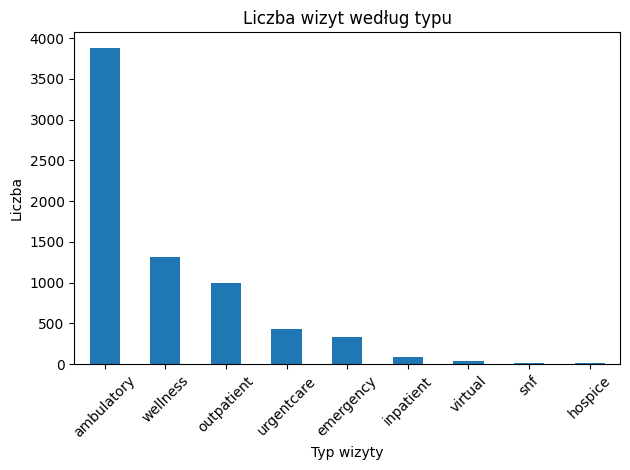

In [23]:
visits['ENCOUNTERCLASS'].value_counts().plot(kind='bar')
plt.title('Liczba wizyt według typu')
plt.xlabel('Typ wizyty')
plt.ylabel('Liczba')
plt.xticks(rotation=45)
plt.tight_layout()

### 2.8.2 Histogram — rozkład wieku podczas wizyt

Text(0, 0.5, 'Liczba wizyt')

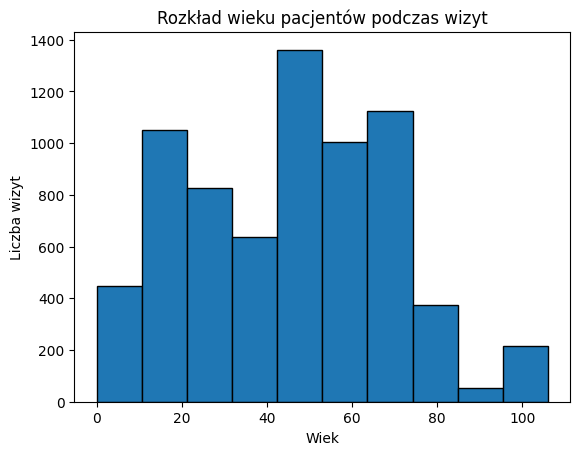

In [24]:
visits['AGE_AT_VISIT'].plot(kind='hist', bins=10, edgecolor='black')
plt.title('Rozkład wieku pacjentów podczas wizyt')
plt.xlabel('Wiek')
plt.ylabel('Liczba wizyt')

### 2.8.3 Boxplot — koszty według typu wizyty

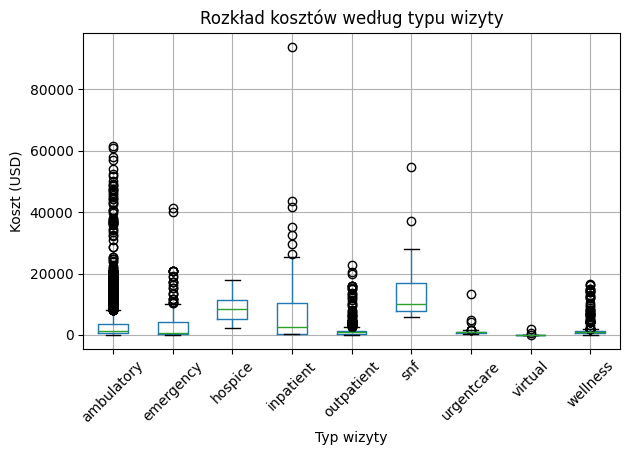

In [25]:
visits.boxplot(column='TOTAL_CLAIM_COST', by='ENCOUNTERCLASS')
plt.title('Rozkład kosztów według typu wizyty')
plt.suptitle('')  # usuwa automatyczny tytuł
plt.xlabel('Typ wizyty')
plt.ylabel('Koszt (USD)')
plt.xticks(rotation=45)
plt.tight_layout()

### 2.8.4 Seaborn — bardziej zaawansowane wizualizacje

Biblioteka seaborn oferuje estetyczne wykresy statystyczne. Wykres słupkowy ze średnimi i przedziałami ufności:

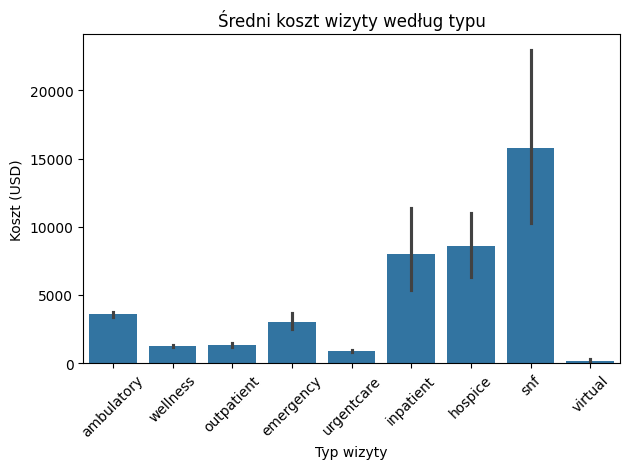

In [26]:
sns.barplot(data=visits, x='ENCOUNTERCLASS', y='TOTAL_CLAIM_COST')
plt.title('Średni koszt wizyty według typu')
plt.xlabel('Typ wizyty')
plt.ylabel('Koszt (USD)')
plt.xticks(rotation=45)
plt.tight_layout()

Wykres pudełkowy z podziałem na płeć:

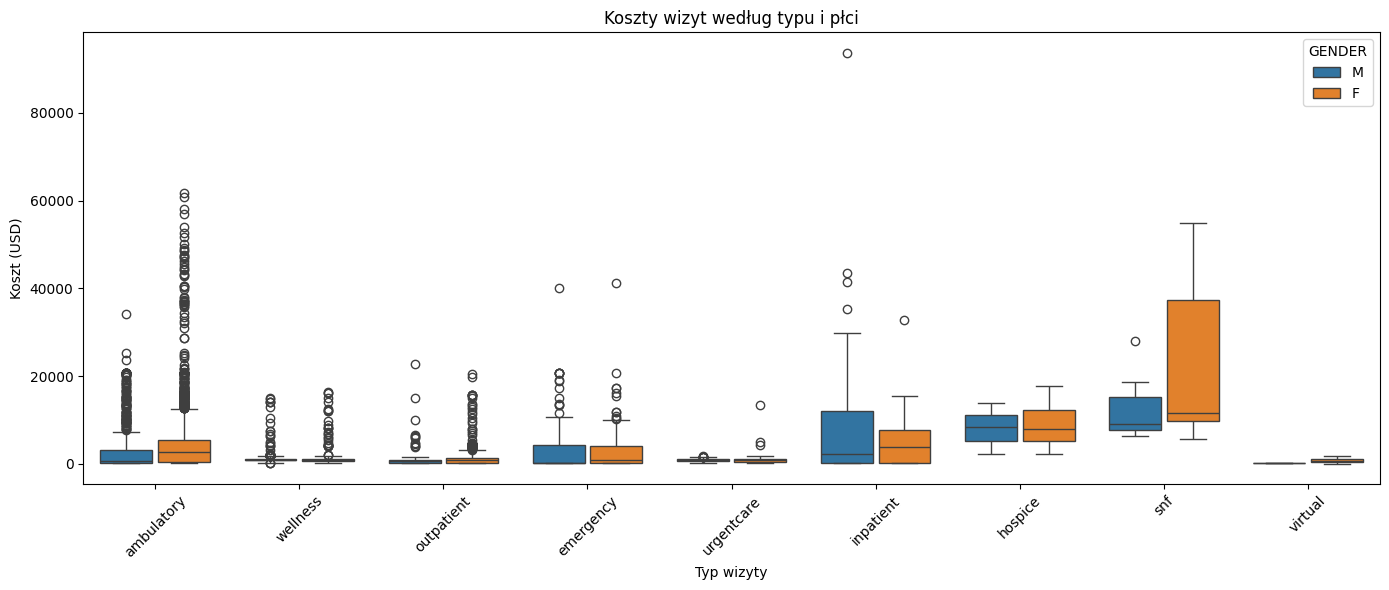

In [27]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=visits, x='ENCOUNTERCLASS', y='TOTAL_CLAIM_COST', hue='GENDER', gap=0.1)
plt.title('Koszty wizyt według typu i płci')
plt.xlabel('Typ wizyty')
plt.ylabel('Koszt (USD)')
plt.xticks(rotation=45)
plt.tight_layout()

## 2.9 Łączenie wielu tabel

### 2.9.1 Analiza diagnoz

Dodajmy do analizy informacje o diagnozach:

In [28]:
visits_with_conditions = pd.merge(
    visits,
    conditions,
    left_on='Id_visit',
    right_on='ENCOUNTER',
    how='left',
    suffixes=('', '_cond')
)

Użyliśmy `how='left'`, aby zachować wszystkie wizyty, nawet te bez diagnozy (np. wizyty profilaktyczne).

### 2.9.2 Najczęstsze diagnozy

In [29]:
conditions['DESCRIPTION'].value_counts().head(10)

DESCRIPTION
Medication review due (situation)    911
Stress (finding)                     373
Gingivitis (disorder)                334
Full-time employment (finding)       333
Part-time employment (finding)       219
Limited social contact (finding)     135
Viral sinusitis (disorder)           134
Social isolation (finding)           124
Not in labor force (finding)         111
Gingival disease (disorder)          104
Name: count, dtype: int64

Lista diagnoz zawiera nie tylko choroby, ale też sytuacje społeczne i administracyjne. Najczęstszą "diagnozą" jest konieczność przeglądu leków (911 przypadków), co wskazuje na starszą populację pacjentów. Stres i problemy stomatologiczne również dominują.

### 2.9.3 Łączenie sekwencyjne

Możemy łączyć wiele tabel po kolei:

In [30]:
full_data = (
    encounters
    .merge(patients, left_on='PATIENT', right_on='Id', suffixes=('_enc', '_pat'))
    .merge(conditions, left_on='Id_enc', right_on='ENCOUNTER', how='left', suffixes=('', '_cond'))
)

Nawiasy pozwalają na rozłożenie operacji na wiele linii, a każde wywołanie `.merge()` zwraca DataFrame, na którym można wywołać kolejne metody (tzw. **method chaining**).

## 2.10 Funkcja `concat()` — łączenie pionowe

Czasami chcemy połączyć tabele "w pionie" — dopisać wiersze z jednej tabeli do drugiej. Służy do tego funkcja `pd.concat()`.

Załóżmy, że mamy dane z dwóch dużych placówek medycznych:

In [31]:
hospital_a = encounters[encounters['ORGANIZATION'] == '979d5316-97f4-335d-af9d-d0afba85dc6a']
hospital_b = encounters[encounters['ORGANIZATION'] == 'acffdfa8-1383-3929-8c99-e73969491439']

print(f"Placówka A: {len(hospital_a)} wizyt")
print(f"Placówka B: {len(hospital_b)} wizyt")

Placówka A: 749 wizyt
Placówka B: 381 wizyt


Połączenie w jedną tabelę:

In [32]:
all_hospitals = pd.concat([hospital_a, hospital_b], ignore_index=True)
print(f"Razem: {len(all_hospitals)} wizyt")

Razem: 1130 wizyt


Parametr `ignore_index=True` tworzy nowy ciągły indeks. Bez niego pandas zachowałby oryginalne indeksy wierszy, co mogłoby prowadzić do duplikatów.

## 2.11 Podsumowanie

### Odpowiedź na pytanie badawcze

Analiza danych Synthea pokazała:

* Mężczyźni generowali więcej wizyt niż kobiety (3746 vs 3349), co częściowo wynika z ich większej liczby w zbiorze (61 vs 54).
* Koszty wizyt różnią się drastycznie w zależności od typu — opieka długoterminowa (snf) kosztuje średnio ~15800 USD, podczas gdy teleporady ~186 USD.
* Wizyty ambulatoryjne (ambulatory) stanowią największą kategorię (3876), co wskazuje na wysokie wykorzystanie opieki podstawowej.
* Kobiety mają wyższe średnie koszty wizyt ambulatoryjnych (4982 vs 2324 USD), ale niższe koszty hospitalizacji (5106 vs 9716 USD).

### Poznane operacje pandas

| Kategoria | Operacje |
|-----------|----------|
| Łączenie tabel | `pd.merge()`, `pd.concat()` |
| Typy złączeń | `how='inner'`, `'left'`, `'right'`, `'outer'` |
| Praca z datami | `pd.to_datetime()`, accessor `.dt` |
| Kategoryzacja | `pd.cut()` |
| Grupowanie zaawansowane | `groupby()` z wieloma kolumnami, `unstack()` |
| Wizualizacja pandas | `.plot(kind='bar')`, `.plot(kind='hist')`, `.boxplot()` |
| Wizualizacja seaborn | `sns.barplot()`, `sns.boxplot()` |

### Co dalej

W następnym wykładzie wykorzystamy połączone dane do przeprowadzenia testów statystycznych — sprawdzimy, czy obserwowane różnice między grupami są istotne statystycznie.